# Árbol de decisión

In [141]:
from datetime import datetime
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

Se carga dataset de features estilométricos.

In [142]:
X_train = pd.read_csv('datasets/X_extra_train.csv')
X_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

In [143]:
ohe_train = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_test = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train = X_train.join(
    pd.DataFrame(
        ohe_train.fit_transform(X_train[['words_count_cat']]),
        index=X_train.index,
        columns=ohe_train.get_feature_names_out(['words_count_cat'])
    )
)
X_test = X_test.join(
    pd.DataFrame(
        ohe_test.fit_transform(X_test[['words_count_cat']]),
        index=X_test.index,
        columns=ohe_test.get_feature_names_out(['words_count_cat'])
    )
)

X_train.drop(['words_count_cat', 'Email Text Raw'], axis=1, inplace=True)
X_test.drop(['words_count_cat', 'Email Text Raw'], axis=1, inplace=True)

In [144]:
classification = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                        max_depth=None, min_samples_split=2,
                                        min_samples_leaf=1, random_state=42)

start_train = datetime.now()
classification.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = classification.predict(X_test)
predict_duration = datetime.now() - start_pred

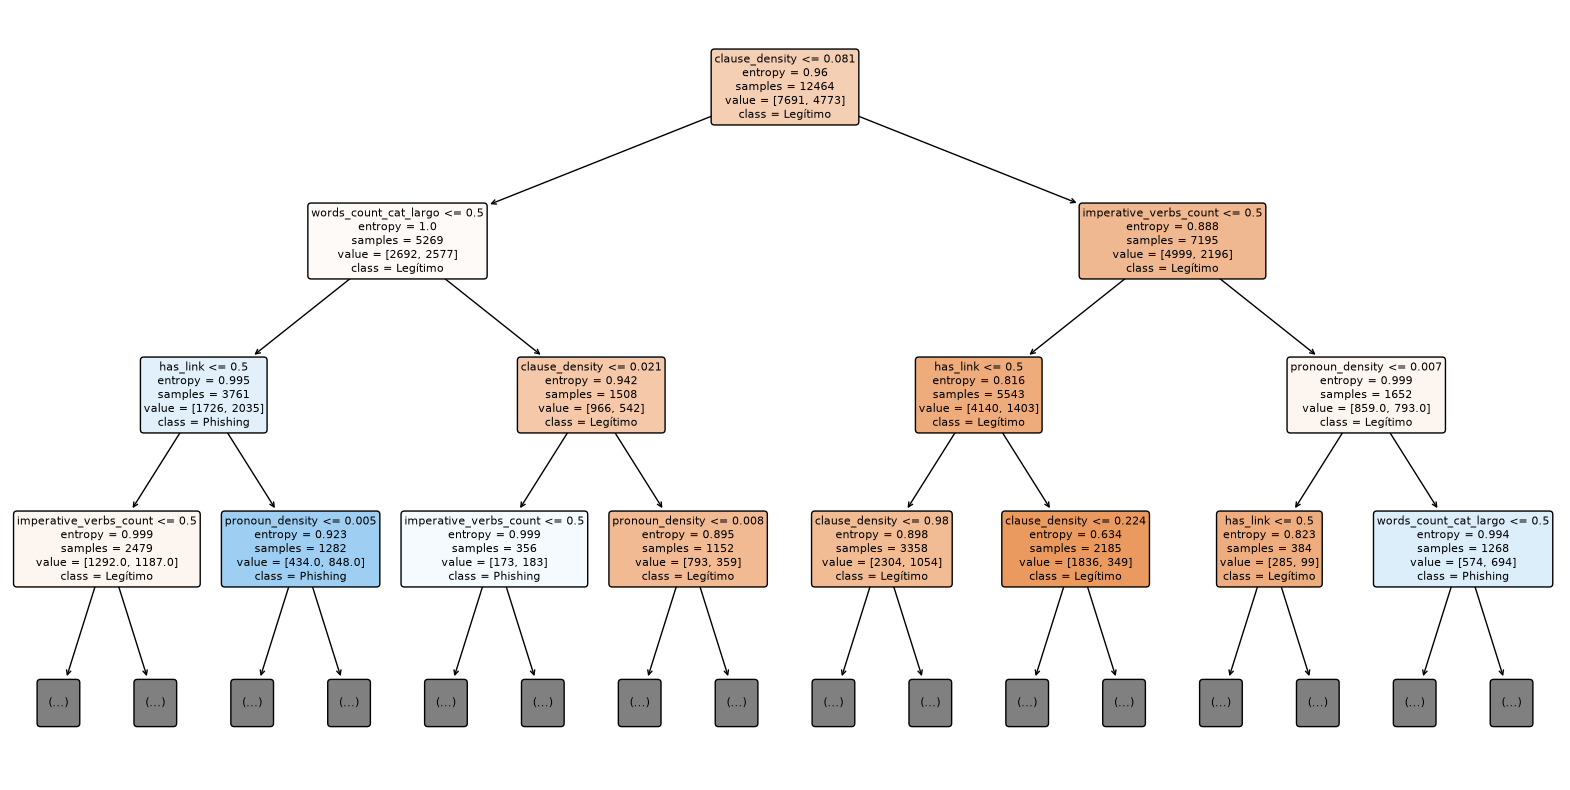

In [145]:
feature_names = X_train.columns

plt.figure(figsize=(20, 10))
plot_tree(classification, feature_names=feature_names, class_names=['Legítimo', 'Phishing'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()

#### Análisis matriz de confusión

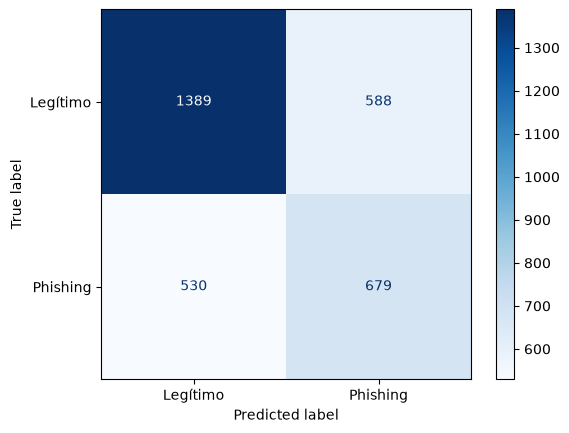

In [146]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [147]:
cm_tree = confusion_matrix(y_test, y_pred)
P = cm_tree[1, :].sum()
N = cm_tree[0, :].sum()
TP = cm_tree[1, 1]
TN = cm_tree[0, 0]

TPR_tree = TP / P
TNR_tree = TN / N
balanced_accuracy_tree = (TPR_tree + TNR_tree) / 2

precision_tree = precision_score(y_test, y_pred, zero_division=0)
recall_tree = recall_score(y_test, y_pred, zero_division=0)
f1_tree = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_tree:.4f}")
print(f"Precisión:               {precision_tree:.4f}")
print(f"Sensibilidad (Recall):   {TPR_tree:.4f}")
print(f"F1-score:                {f1_tree:.4f}")
print(f"Especificidad:           {TNR_tree:.4f}")
print(f"Recuperación (Recall):   {recall_tree:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6321
Precisión:               0.5359
Sensibilidad (Recall):   0.5616
F1-score:                0.5485
Especificidad:           0.7026
Recuperación (Recall):   0.5616
Tiempo de entrenamiento: 0:00:00.075324
Tiempo de predicción:    0:00:00.002672


#### Curva Roc

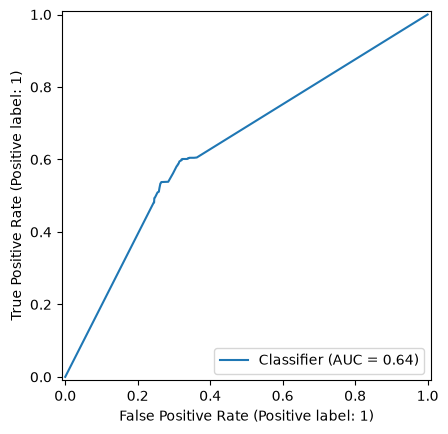

In [148]:
y_scores = classification.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Pobretón.

#### Profunidad y features

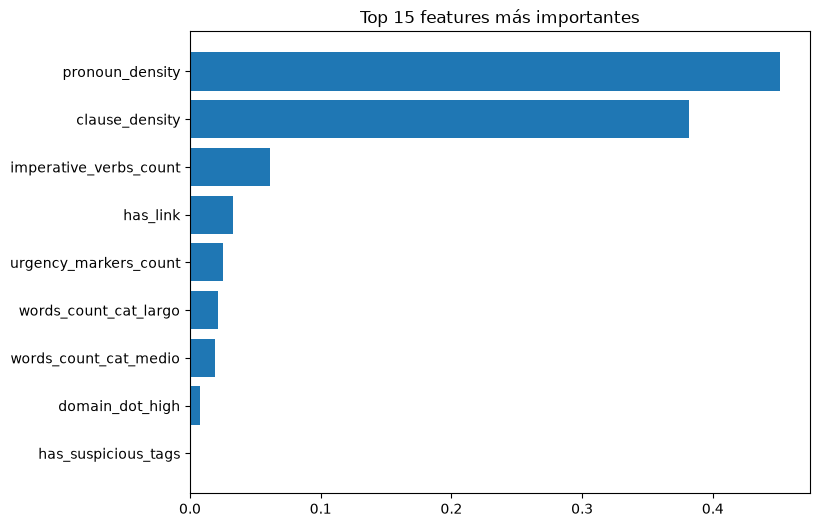

Profundidad del árbol: 48
Cantidad de hojas: 3351


In [149]:
importances = classification.feature_importances_
top_idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8,6))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx])
plt.title('Top 15 features más importantes')
plt.show()

print(f"Profundidad del árbol: {classification.get_depth()}")
print(f"Cantidad de hojas: {classification.get_n_leaves()}")

## Optimización de parámetros

Se define la función objetivo y se prepara el estudio.

In [150]:
def objective(trial):
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    splitter = trial.suggest_categorical("splitter", ["best", "random"])
    max_depth = trial.suggest_int("max_depth", 2, 32)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    model = DecisionTreeClassifier(criterion=criterion, splitter=splitter,
                                        max_depth=max_depth, min_samples_split=min_samples_split,
                                        min_samples_leaf=min_samples_leaf, random_state=42)

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 500 trials.

In [151]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=500, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 0 achieved value: 0.5290697257289686
Trial 2 achieved value: 0.5573741450780928 with  5.0782% improvement
Trial 3 achieved value: 0.5745391484626361 with  2.9876% improvement
Trial 46 achieved value: 0.5808051274837553 with  1.0788% improvement
Trial 47 achieved value: 0.5810197982500771 with  0.0369% improvement
Trial 58 achieved value: 0.581030874873846 with  0.0019% improvement
Trial 61 achieved value: 0.5810811875311934 with  0.0087% improvement
Trial 125 achieved value: 0.5875938677079632 with  1.1084% improvement


In [152]:
best_params = study.best_params
best_params

{'criterion': 'log_loss',
 'splitter': 'random',
 'max_depth': 29,
 'min_samples_split': 11,
 'min_samples_leaf': 3}

Se entrena el modelo con los parámetros resultantes de la optimización.

In [153]:
optimized_classification = DecisionTreeClassifier(**best_params, random_state=42)

start_train_opt = datetime.now()
optimized_classification.fit(X_train, y_train)
train_duration_opt = datetime.now() - start_train_opt

start_pred_opt = datetime.now()
y_pred = optimized_classification.predict(X_test)
predict_duration_opt = datetime.now() - start_pred_opt

#### Métricas

Se evalúa.

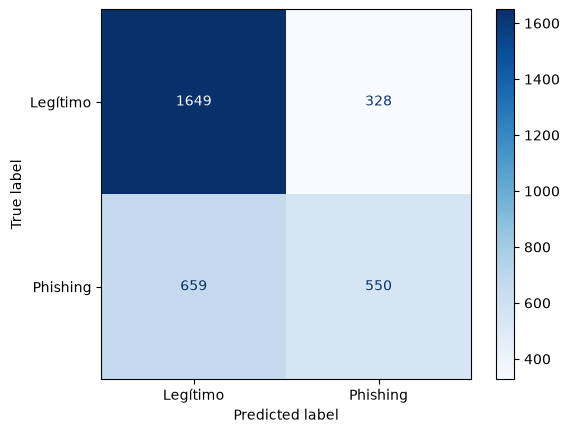

In [154]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [155]:
cm_optimized_tree = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_tree[1, :].sum()
N_opt = cm_optimized_tree[0, :].sum()
TP_opt = cm_optimized_tree[1, 1]
TN_opt = cm_optimized_tree[0, 0]

TPR_tree_opt = TP_opt / P_opt
TNR_tree_opt = TN_opt / N_opt
balanced_accuracy_tree_opt = (TPR_tree_opt + TNR_tree_opt) / 2

precision_tree_opt = precision_score(y_test, y_pred, zero_division=0)
recall_tree_opt = recall_score(y_test, y_pred, zero_division=0)
f1_tree_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_tree:.4f}          {balanced_accuracy_tree_opt:.4f}")
print(f"Precisión:               {precision_tree:.4f}          {precision_tree_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_tree:.4f}          {TPR_tree_opt:.4f}")
print(f"F1-score:                {f1_tree:.4f}          {f1_tree_opt:.4f}")
print(f"Especificidad:           {TNR_tree:.4f}          {TNR_tree_opt:.4f}")
print(f"Recuperación (Recall):   {recall_tree:.4f}          {recall_tree_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6321          0.6445
Precisión:               0.5359          0.6264
Sensibilidad (Recall):   0.5616          0.4549
F1-score:                0.5485          0.5271
Especificidad:           0.7026          0.8341
Recuperación (Recall):   0.5616          0.4549
Tiempo de entrenamiento: 0:00:00.075324  0:00:00.020881
Tiempo de predicción:    0:00:00.002672  0:00:00.002325


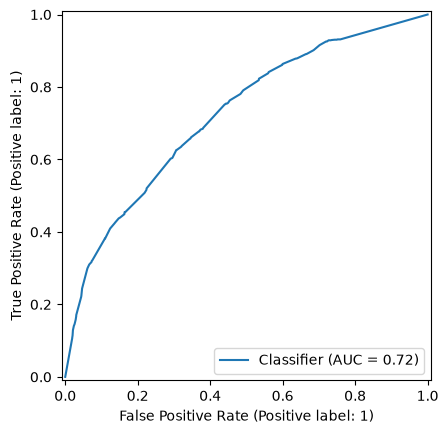

In [156]:
y_scores = optimized_classification.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Bueno, no sirvió mucho. Y eso que le dimos trials con Optuna...